In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dolfinx import mesh, fem, default_scalar_type
from dolfinx.fem.petsc import NonlinearProblem, LinearProblem
from mpi4py import MPI
import ufl
from petsc4py import PETSc
from my_functions import *
from visualization_fct import *

## Set up mesh and FE spaces

In [2]:
# Define geometry
P0 = np.array([0, 0])
P1 = np.array([6, -1])
P2 = np.array([6, 2])
P3 = np.array([0, 3])
slope = (P1[1]-P0[1])/(P1[0]-P0[0])

delta_x = delta_z = 0.05
nx = int(6/delta_x)
nz = int(3/delta_x)
print(f"Resolution is dx = {delta_x} m, dz = {delta_z} m, giving nx = {nx}, nz = {nz}")

# Generate mesh from corner points
domain = create_quad_domain(MPI.COMM_WORLD, nx, nz, P0, P1, P2, P3, celltype=mesh.CellType.quadrilateral)

# Initialize functionspace, test function, coordinates
Q = fem.functionspace(domain, ("DG", 0)) # material parameters
V = fem.functionspace(domain, ("CG", 1)) # pressure head
v = ufl.TestFunction(V)
x = ufl.SpatialCoordinate(domain)

Resolution is dx = 0.05 m, dz = 0.05 m, giving nx = 120, nz = 60


## Set up heterogeneous material

In [3]:

# -------------------------------------------------
# DG0 parameter fields
# -------------------------------------------------

Ks      = fem.Function(Q)
alpha   = fem.Function(Q)
n_vg    = fem.Function(Q)
theta_r = fem.Function(Q)
theta_s = fem.Function(Q)

# -------------------------------------------------
# Material assignment
# -------------------------------------------------

# Define parameters for each layer (layer 1, top: sand, layer 2, bottom: silt)
layer_params = {
    1: {"name": "loam", "alpha": 3.6, "N": 1.56, "theta_r": 0.078, "theta_s": 0.43, "Ks": 2.89e-6, "locator": lambda x: False},
    2: {"name": "sand", "alpha": 14.5, "N": 2.68, "theta_r": 0.045, "theta_s": 0.43, "Ks": 8.25e-5, "locator": lambda x: x[1] >= slope*x[0] + P3[1]/2 - 1e-14},
    3: {"name": "silt", "alpha": 1.6, "N": 1.37, "theta_r": 0.034, "theta_s": 0.46, "Ks": 6.94e-7, "locator": lambda x: x[1] < slope*x[0] + P3[1]/2 - 1e-14},
}

tdim = domain.topology.dim
num_cells = domain.topology.index_map(tdim).size_local
cells = np.arange(num_cells, dtype=np.int32)

midpoints = mesh.compute_midpoints(domain, tdim, cells)

Ks_vals      = np.zeros(num_cells)
alpha_vals   = np.zeros(num_cells)
n_vals       = np.zeros(num_cells)
theta_r_vals = np.zeros(num_cells)
theta_s_vals = np.zeros(num_cells)

for c, x in enumerate(midpoints):
    # Check in which layer the midpoint is and assign the corresponding parameters
    for key, value in layer_params.items():
        if value["locator"](x):
            Ks_vals[c] = value["Ks"]
            alpha_vals[c] = value["alpha"]
            n_vals[c] = value["N"]
            theta_r_vals[c] = value["theta_r"]
            theta_s_vals[c] = value["theta_s"]

# -------------------------------------------------
# Store into DG0 functions
# -------------------------------------------------

Ks.x.array[:] = Ks_vals
alpha.x.array[:] = alpha_vals
n_vg.x.array[:] = n_vals
theta_r.x.array[:] = theta_r_vals
theta_s.x.array[:] = theta_s_vals

Ks.x.scatter_forward()
alpha.x.scatter_forward()
n_vg.x.scatter_forward()
theta_r.x.scatter_forward()
theta_s.x.scatter_forward()


In [4]:
# -------------------------------------------------
# Define parametrizations
# -------------------------------------------------

# van Genuchten
def S_e(h_w, alpha, N):
    return ufl.conditional(ufl.lt(h_w, 0), (1 + (- alpha * h_w)**N)**((1 - N) / N), 1)
def theta(Se, theta_r, theta_s):
    return theta_r + (theta_s - theta_r)*Se
def k_rel(Se, N):
    m = 1 - 1/N
    return ufl.conditional(ufl.lt(Se, 1 - 1e-7), ufl.sqrt(Se) * (1 - (1 - Se**(1/m))**m)**2 , 1)
def C(S, N):
    m = 1 - 1/N
    Sm = S**(1/m)
    Cval = ufl.conditional(Sm < 1, alpha * m * (theta_s - theta_r) * N * Sm * (1 - Sm)**m, 0)
    return Cval


2026-05-26 14:33:47.621 (   6.469s) [    7605C13E4600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card2: Permission denied

2026-05-26 14:33:47.643 (   6.492s) [    7605C13E4600] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x5b8bac1b01a0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card2: Permission denied

2026-05-26 14:33:47.662 (   6.510s) [    7605C13E4600] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x5b8bac1b60a0): EGL device index: 0 could not be initialized.

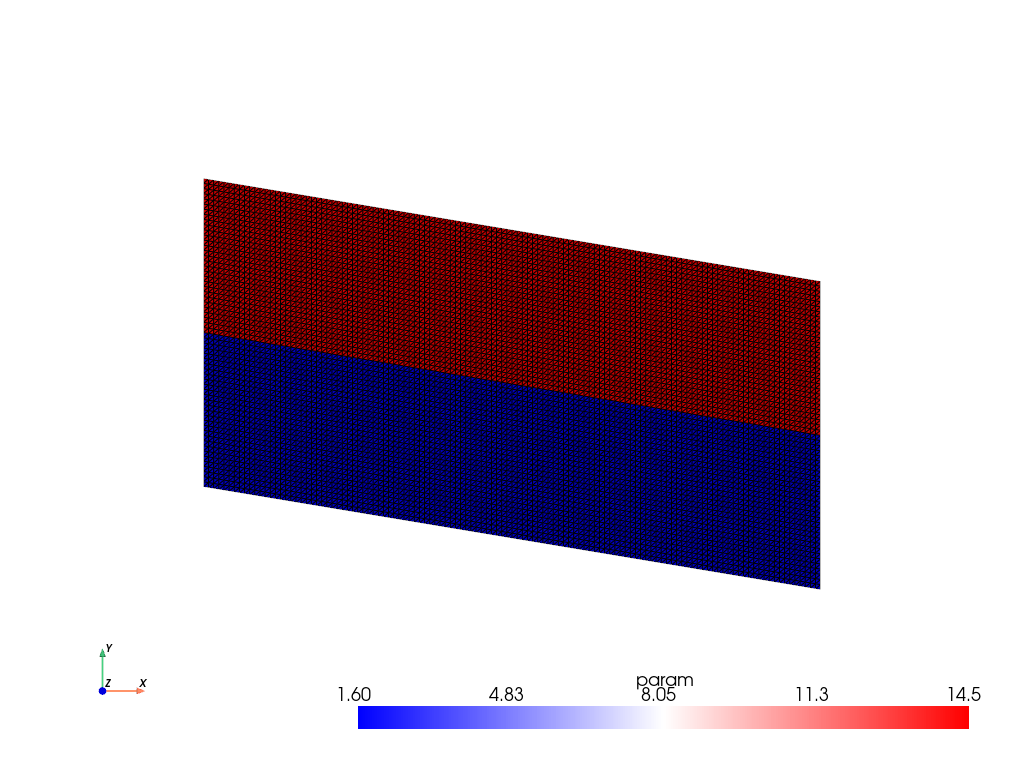

In [5]:
import pyvista
from dolfinx import plot

pyvista.set_jupyter_backend("static")

topology, cell_types, geometry = plot.vtk_mesh(domain, 2)
grid = pyvista.UnstructuredGrid(topology, cell_types, geometry)
grid.cell_data["param"] = alpha.x.array
grid.set_active_scalars("param")
# Create plotter and pyvista grid
p = pyvista.Plotter()
p.add_mesh(grid, show_edges=True, cmap="bwr")
p.view_xy()
p.show_axes()
p.show()

## Boundary conditions

In [5]:
# Boundary condition locators
def on_dirichlet(x):
    return np.logical_and(np.isclose(x[0], P1[0]), x[1] <= 0)

def top(x):
    return np.isclose(x[1], slope*x[0]+P3[1])

# Dirichlet boundary
def dirichlet(x):
    return -x[1]
dofs_D = fem.locate_dofs_geometrical(V, on_dirichlet)
u_D = fem.Function(V)
u_D.interpolate(dirichlet)
bc = fem.dirichletbc(u_D, dofs_D)

# Inflow (Neumann) boundary
tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)
boundary_facets = mesh.exterior_facet_indices(domain.topology) 
facets_on_top = mesh.locate_entities(domain, fdim, top)
facets_not_top = np.setdiff1d(boundary_facets, facets_on_top)
# Mark facets belonging to inflow boundary with 1
facet_markers = np.zeros_like(boundary_facets)
facet_markers[:len(facets_on_top)] = 1
facet_indices = np.hstack([facets_on_top, facets_not_top])
sorted_facets = np.argsort(facet_indices)
# Create meshtags for facets (marker = 1 for inflow boundary)
facet_tags = mesh.meshtags(domain, fdim, facet_indices[sorted_facets], facet_markers[sorted_facets]) 
# Create custom integration measure for inflow boundary
ds = ufl.Measure("ds", domain, subdomain_data=facet_tags)
# Recharge
c_in = fem.Constant(domain, PETSc.ScalarType(2e-9))
inflow = - v * c_in * ds(1)

## Start solving

In [6]:
# Time discretization
t = 0.0 # start time [s]
T = 24*60*60 # end time [s]
delta_t = 7 # time step [s]

#### Picard

In [12]:
v = ufl.TestFunction(V)
u_n = fem.Function(V)
u_n.x.array[:] = -1e-6*np.ones_like(u_n.x.array) # previous (time step) solution

max_iter = 20 # maximum number of Picard iterations
tol = 1e-6

delta_u = 1
it = 1

while t <= T:
    it += 1
    u_m = fem.Function(V)
    u_m.x.array[:] = u_n.x.array # First guess for Picard: previous time step
    du = ufl.TrialFunction(V)
    
    # Build variational formulation
    Sat_m = S_e(u_m, alpha, n_vg)
    Sat_n = S_e(u_n, alpha, n_vg)
    conductivity = k_rel(Sat_m, n_vg) * Ks
    theta_n = theta(Sat_n, theta_r, theta_s)
    theta_m = theta(Sat_m, theta_r, theta_s)

    C_part = 1/delta_t * C(Sat_m, n_vg) * du * v * ufl.dx
    var_part = ufl.dot(conductivity * ufl.grad(du), ufl.grad(v)) * ufl.dx
    rest = ufl.dot(conductivity * ufl.grad(u_m + x[1]), ufl.grad(v)) * ufl.dx + (theta_m - theta_n) / delta_t  * v * ufl.dx - v*c_in*ds(4)
    F = C_part + var_part + rest

    a_fem = ufl.lhs(F)
    L_fem = ufl.rhs(F)

    #du = Function(V)
    u_mp1 = fem.Function(V)

    # Prepare Picard iteration
    m = 0 # iteration count
    eps = 1

    while eps > tol and m < max_iter:
        # Calculate boundary conditions for du: du@bd = u_D - u_m@bd
        du_Dirichlet = fem.Function(V)
        du_Dirichlet.interpolate(dirichlet)
        du_Dirichlet.x.array[:] = du_Dirichlet.x.array - u_m.x.array
        bc_du = fem.dirichletbc(du_Dirichlet, dofs_D)

        problem = LinearProblem(
            a_fem, L_fem, bcs=[bc_du],
            petsc_options={"ksp_type": "preonly", "pc_type": "lu"},
            petsc_options_prefix="Picard_"
            )
        du = problem.solve()
        u_mp1.x.array[:] = u_m.x.array + du.x.array # make sure capillary head stays nonpositive
        eps = np.linalg.norm(du.x.array, ord=np.inf)
        print(f"Time {it*delta_t} s, iteration {m}, Error ||u_n^m-u_n^(m+1)|| {eps:.3e}")
        u_m.x.array[:] = u_mp1.x.array
        m += 1

    # Adaptive time stepping:
    if m > max_iter and delta_t > 5e-1:
        delta_t *= 0.5
        continue
    if m < 3:
        delta_t *= 1.2

    t += delta_t
    u_n.x.array[:] = u_mp1.x.array

Time 14 s, iteration 0, Error ||u_n^m-u_n^(m+1)|| 1.000e+00
Time 14 s, iteration 1, Error ||u_n^m-u_n^(m+1)|| 8.121e-02
Time 14 s, iteration 2, Error ||u_n^m-u_n^(m+1)|| 3.081e-02
Time 14 s, iteration 3, Error ||u_n^m-u_n^(m+1)|| 1.494e-02
Time 14 s, iteration 4, Error ||u_n^m-u_n^(m+1)|| 3.235e-01
Time 14 s, iteration 5, Error ||u_n^m-u_n^(m+1)|| 1.328e-01
Time 14 s, iteration 6, Error ||u_n^m-u_n^(m+1)|| 1.093e-02
Time 14 s, iteration 7, Error ||u_n^m-u_n^(m+1)|| 1.861e-01
Time 14 s, iteration 8, Error ||u_n^m-u_n^(m+1)|| 8.877e-02
Time 14 s, iteration 9, Error ||u_n^m-u_n^(m+1)|| 1.396e-02
Time 14 s, iteration 10, Error ||u_n^m-u_n^(m+1)|| 1.303e-01
Time 14 s, iteration 11, Error ||u_n^m-u_n^(m+1)|| 4.880e-02
Time 14 s, iteration 12, Error ||u_n^m-u_n^(m+1)|| 4.378e-02
Time 14 s, iteration 13, Error ||u_n^m-u_n^(m+1)|| 1.041e-01
Time 14 s, iteration 14, Error ||u_n^m-u_n^(m+1)|| 2.661e-02
Time 14 s, iteration 15, Error ||u_n^m-u_n^(m+1)|| 4.697e-02
Time 14 s, iteration 16, Error ||u

libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card2: Permission denied

2026-05-26 14:17:28.599 ( 371.676s) [    780A316EE600] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x55ebf1251320): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card1: Permission denied

libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware device.
libEGL warning: failed to open /dev/dri/card2: Permission denied

2026-05-26 14:17:28.609 ( 371.687s) [    780A316EE600] vtkEGLRenderWindow.cxx:359   WARN| vtkEGLRenderWindow (0x55ebf1253120): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: Not allowed to force software rendering when API explicitly selects a hardware devi

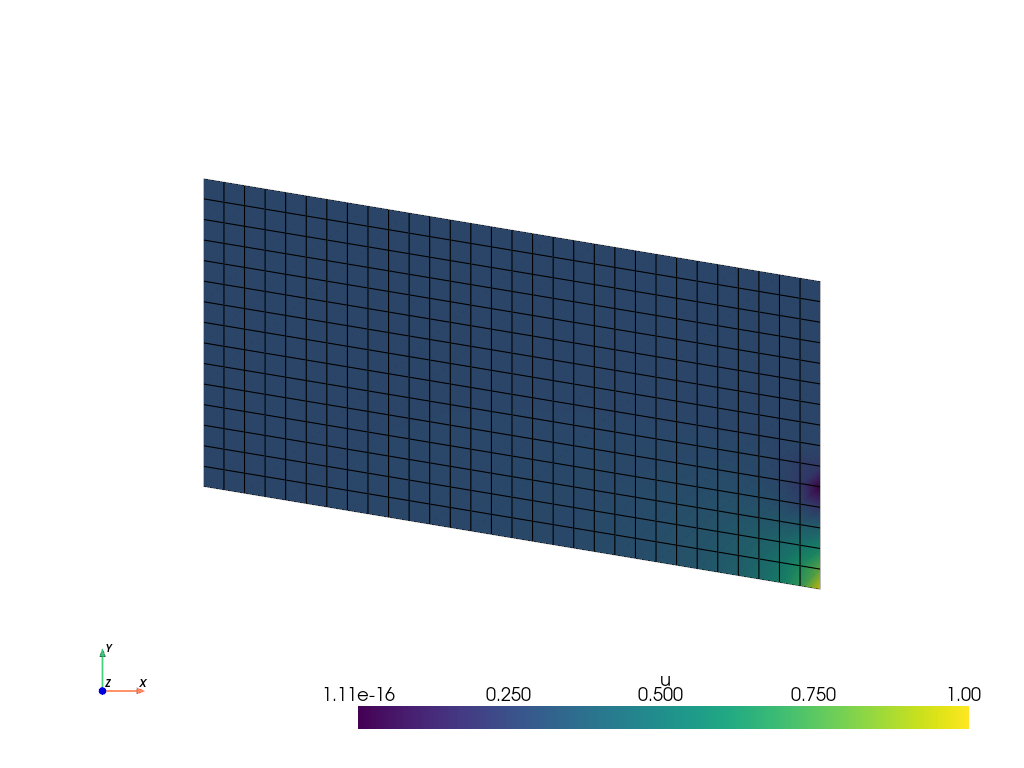

In [13]:
plotScalarFunction(V, u_n)

#### Newton:

In [ ]:
def solve_Nonlinear_Newton(F, V, y_ini, t, T_end, petsc_options, delta_t = 7, save_tmp = False):
    y_old = fem.Function(V)
    y_old.interpolate(y_ini) # initial condition
    

In [21]:
# Time discretization
t = 0.0 # start time [s]
T = 16*60*60 # end time [s]
delta_t = 7 # time step [s]

# Variational formulation
h_w_old = fem.Function(V)
h_w_old.name = "h_w_old"
h_w_old.x.array[:] = -1e-1*np.ones_like(h_w_old.x.array) # initial condition close to saturation

h_w_new = fem.Function(V)
h_w_new.x.array[:] = h_w_old.x.array

z = x[1]

petsc_options = {
    "snes_type": "newtonls",
    "snes_linesearch_type": "bt",
    "snes_atol": 1e-11,
    "snes_rtol": 1e-4,
    "snes_monitor_cancel": None,
    "snes_maxit": 20,
    "ksp_error_if_not_converged": True,
    "ksp_type": "gmres",
    "ksp_rtol": 1e-5,
    "ksp_monitor_cancel": None,
    "pc_type": "hypre",
    "pc_hypre_type": "boomeramg",
    "pc_hypre_boomeramg_max_iter": 1,
    "pc_hypre_boomeramg_cycle_type": "v",
}

while t <= T:
    

    # Initial guess for Newton
    h_w_new.x.array[:] = h_w_old.x.array

    # Weak formulation
    F = (theta(S_e(h_w_new, alpha, n_vg), theta_r, theta_s) - theta(S_e(h_w_old, alpha, n_vg), theta_r, theta_s)) / delta_t * v * ufl.dx
    F += ufl.dot(ufl.grad(v), Ks * k_rel(S_e(h_w_new, alpha, n_vg), n_vg) * ufl.grad(z + h_w_new)) * ufl.dx
    F += inflow
    problem = NonlinearProblem(
        F,
        h_w_new,
        bcs=[bc],
        petsc_options=petsc_options,
        petsc_options_prefix="richards",
    )
    h_w_new = problem.solve()
    converged = problem.solver.getConvergedReason()
    num_iter = problem.solver.getIterationNumber()

    # adaptive time stepping:
    if num_iter > 10 and delta_t > 1e-1:
        delta_t *= 0.5
        continue
    if num_iter < 3:
        delta_t *= 1.2
    
    assert converged > 0, f"Solver did not converge, got {converged}."
    print(
        f"Solver converged after {num_iter} iterations with converged reason {converged}. Time step is {delta_t:.2f} s at t={(t)/3600:.2f} hours."
    )
  
    # update time 
    t += delta_t
    # update old solution
    h_w_old.x.array[:] = h_w_new.x.array
    

Solver converged after 1 iterations with converged reason 3. Time step is 8.40 s at t=0.00 hours.
Solver converged after 3 iterations with converged reason 2. Time step is 8.40 s at t=0.00 hours.
Solver converged after 3 iterations with converged reason 3. Time step is 8.40 s at t=0.00 hours.
Solver converged after 3 iterations with converged reason 3. Time step is 8.40 s at t=0.01 hours.
Solver converged after 3 iterations with converged reason 3. Time step is 8.40 s at t=0.01 hours.
Solver converged after 3 iterations with converged reason 3. Time step is 8.40 s at t=0.01 hours.
Solver converged after 3 iterations with converged reason 3. Time step is 8.40 s at t=0.01 hours.
Solver converged after 3 iterations with converged reason 3. Time step is 8.40 s at t=0.02 hours.
Solver converged after 4 iterations with converged reason 3. Time step is 8.40 s at t=0.02 hours.
Solver converged after 4 iterations with converged reason 3. Time step is 8.40 s at t=0.02 hours.
Solver converged aft

In [26]:
np.save("heterogen_16h_initial-1e-1", h_w_new.x.array)

## Evaluate solution

In [ ]:
h_w_new = fem.Function(V)
h_w_new.x.array[:] = np.load("heterogen_16h_initial-1e-1.npy")

In [22]:
# Evaluate solution
n = 100
grid, x_grid, z_grid = get_grid(P0, P1, P2, P3, n)
pressure_head = eval_fct_on_grid(grid, h_w_new, domain).reshape((n,n))
alpha_eval = eval_fct_on_grid(grid, alpha, domain).reshape((n,n))
N_eval = eval_fct_on_grid(grid, n_vg, domain).reshape((n,n))
theta_r_eval = eval_fct_on_grid(grid, theta_r, domain).reshape((n,n))
theta_s_eval = eval_fct_on_grid(grid, theta_s, domain).reshape((n,n))
h_tot = pressure_head + z_grid
h_c = pressure_head * (pressure_head <= 0)
def S_e1(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = theta_r_eval + (theta_s_eval - theta_r_eval)*S_e1(h_c.flatten(), alpha_eval.flatten(), N_eval.flatten()).reshape((n,n))

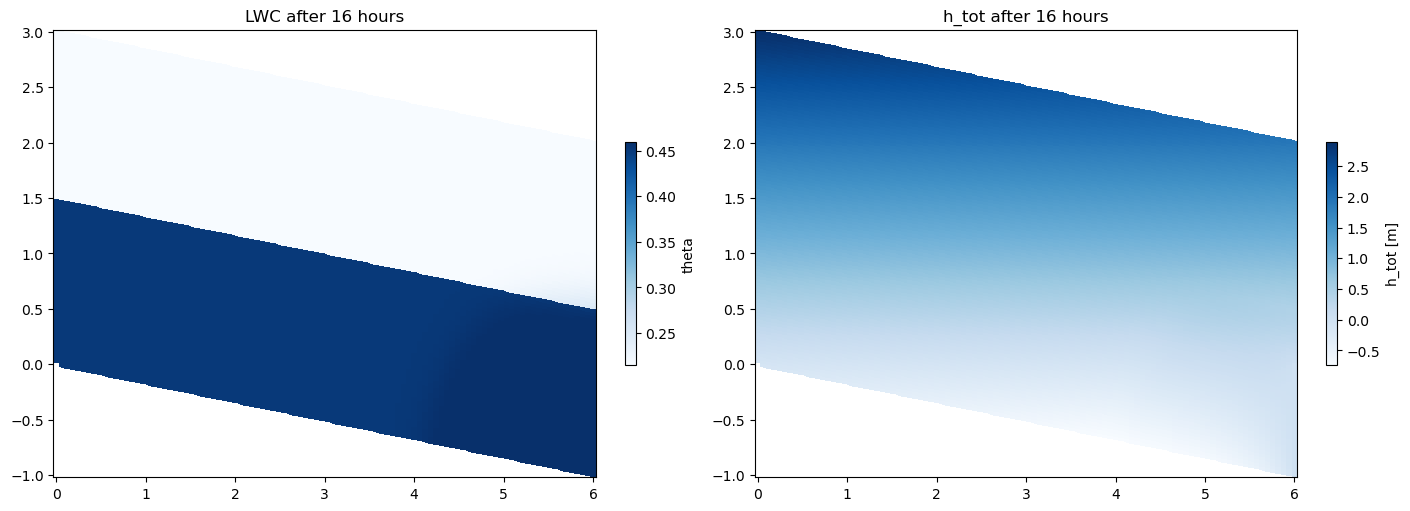

In [23]:
# Plot solution

fig, ax = plt.subplots(1,2, layout="constrained", figsize=(14,5))
pmsh1 = ax[0].pcolormesh(x_grid, z_grid, theta_tot, cmap="Blues")
ax[0].set_title(f"LWC after {T/3600:.0f} hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[1].pcolormesh(x_grid, z_grid, h_tot, cmap="Blues")
ax[1].set_title(f"h_tot after {T/3600:.0f} hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[1], shrink=0.5)
cbar2.set_label("h_tot [m]")

In [16]:
import pickle

# open pickle file and load
with open("Test_Annika_heterogen.pkl", "rb") as f:
    data = pickle.load(f)

Exception ignored in: <function NonlinearProblem.__del__ at 0x7604c05e3600>
Traceback (most recent call last):
  File "/home/annika/miniconda3/envs/fenicsx-env/lib/python3.11/site-packages/dolfinx/fem/petsc.py", line 1361, in __del__
    lambda obj: obj is not None, (self._snes, self._A, self._b, self._x, self._P_mat)
                                  ^^^^^^^^^^
AttributeError: 'NonlinearProblem' object has no attribute '_snes'
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [17]:
anne_x = data["X_plot"]
anne_z = data["Z_plot"]
anne_theta = data["theta_l_total"][24]
anne_h_tot = data["h_total"][24]
anne_h_c = data["h_c_total"][24]

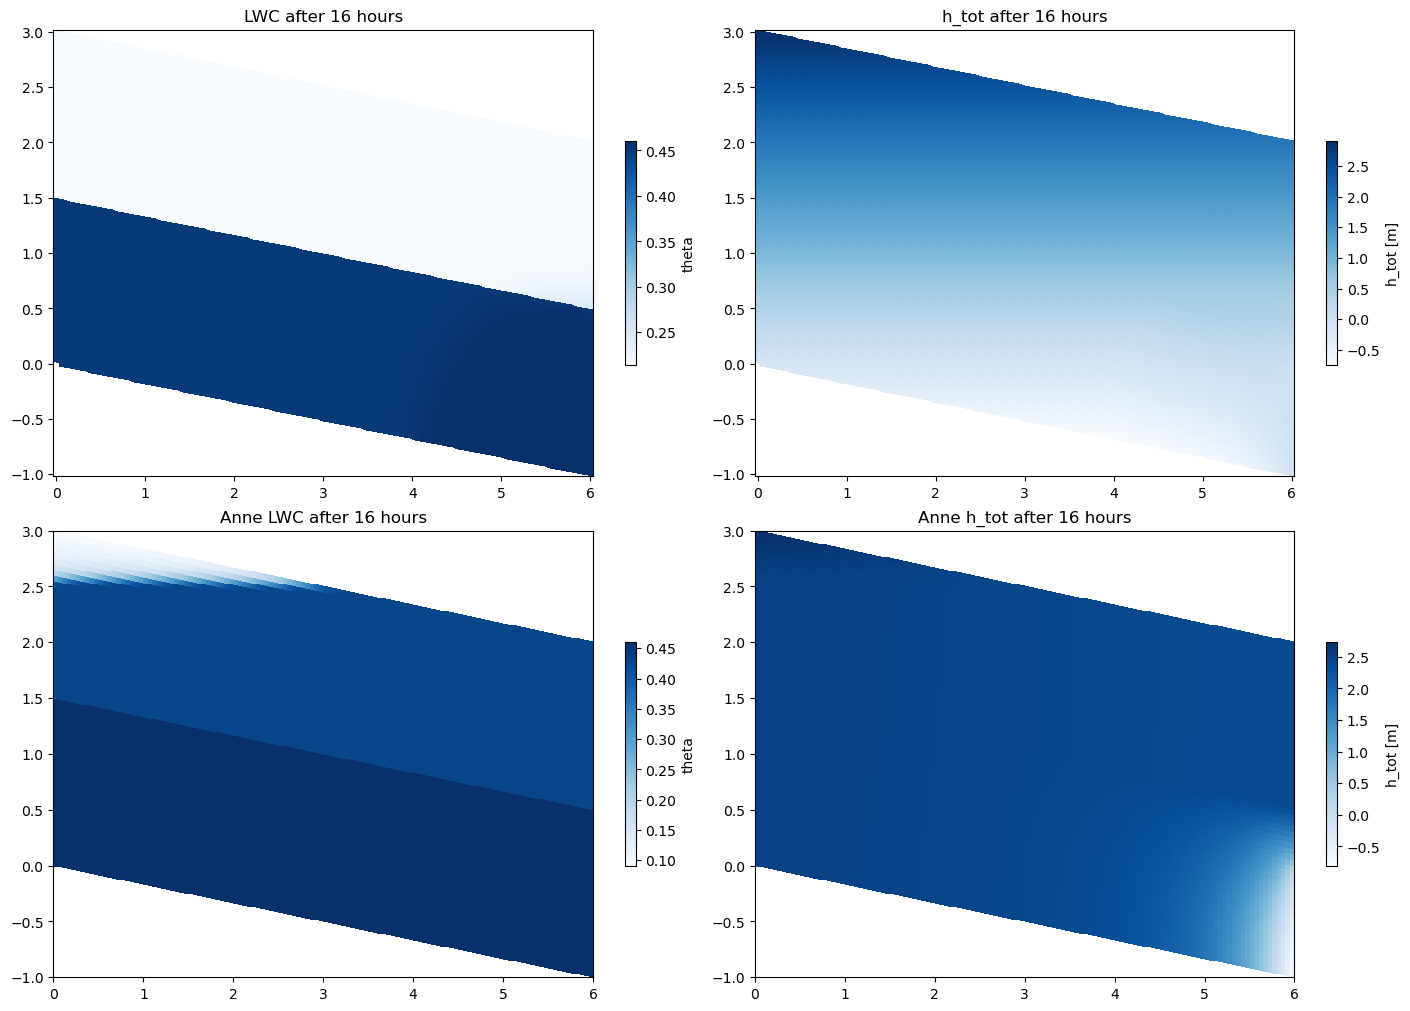

In [24]:
anne_grid, anne_x_grid, anne_z_grid = get_grid(P0, P1, P2, P3, 20)

fig, ax = plt.subplots(2,2, layout="constrained", figsize=(14,10))
pmsh1 = ax[0, 0].pcolormesh(x_grid, z_grid, theta_tot, cmap="Blues")
ax[0, 0].set_title(f"LWC after {T/3600:.0f} hours")
cbar1 = fig.colorbar(pmsh1, ax=ax[0, 0], shrink=0.5)
cbar1.set_label("theta")

pmsh2 = ax[0, 1].pcolormesh(x_grid, z_grid, h_tot, cmap="Blues")
ax[0, 1].set_title(f"h_tot after {T/3600:.0f} hours")
cbar2 = fig.colorbar(pmsh2, ax=ax[0, 1], shrink=0.5)
cbar2.set_label("h_tot [m]")

pmsh11 = ax[1, 0].pcolormesh(anne_x, anne_z, anne_theta, cmap="Blues", shading="flat")
ax[1, 0].set_title(f"Anne LWC after {T/3600:.0f} hours")
cbar1 = fig.colorbar(pmsh11, ax=ax[1, 0], shrink=0.5)
cbar1.set_label("theta")

pmsh12 = ax[1, 1].pcolormesh(anne_x, anne_z, anne_h_tot, cmap="Blues", shading="flat")
ax[1, 1].set_title(f"Anne h_tot after {T/3600:.0f} hours")
cbar2 = fig.colorbar(pmsh12, ax=ax[1, 1], shrink=0.5)
cbar2.set_label("h_tot [m]")

In [25]:
theta_tot

array([[       nan, 0.4511101 , 0.4511101 , ..., 0.46      , 0.46      ,
        0.46      ],
       [0.4511101 , 0.4511101 , 0.4511101 , ..., 0.46      , 0.46      ,
        0.46      ],
       [0.4511101 , 0.4511101 , 0.4511101 , ..., 0.46      , 0.46      ,
        0.46      ],
       ...,
       [0.21485769, 0.21483967, 0.21482628, ..., 0.21477042, 0.21475854,
        0.21474207],
       [0.21492348, 0.21490455, 0.21489053, ..., 0.21483343, 0.2148214 ,
        0.21480411],
       [0.2149919 , 0.21497225, 0.21495769, ..., 0.21489979, 0.21488782,
        0.21487002]], shape=(100, 100))